## 공통함수 정의

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.tree import export_graphviz
import graphviz
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

import os
os.chdir("/home/piai/Desktop/git/2. Big Data 분석")

In [2]:
import matplotlib

matplotlib.rc("font", family = "NanumSquare")
matplotlib.rc('axes', unicode_minus=False)

In [3]:
df_raw = pd.read_csv("보험료.csv", encoding = "euc-kr")
df_raw.head()

,고객번호,성별,나이,BMI,자녀수,흡연여부,가입유형,납부유형,보장범위,납입기간,보험료
0,ID100001,남성,19,27.9,0,1,홈쇼핑,은행,19,40,168849
1,ID100002,여성,18,33.8,1,0,인터넷,은행,10,40,17255
2,ID100003,여성,28,33.0,3,0,상담사,카드,12,30,44494
3,ID100004,여성,33,22.7,0,0,홈쇼핑,지로,15,30,219844
4,ID100005,여성,32,28.9,0,0,인터넷,카드,9,30,38668


## 결측치 처리

In [4]:
df_raw.isnull().sum()

고객번호    0
성별      0
나이      0
BMI     0
자녀수     0
흡연여부    0
가입유형    2
납부유형    3
보장범위    0
납입기간    0
보험료     0
dtype: int64

In [5]:
df_raw['가입유형'].fillna(df_raw['가입유형'].mode()[0], inplace = True)
df_raw['납부유형'].fillna(df_raw['납부유형'].mode()[0], inplace = True)

df_raw = df_raw.drop(['고객번호'], axis = 1)

df_raw_dummy = pd.get_dummies(df_raw, drop_first = True)
df_raw_dummy.head()

,나이,BMI,자녀수,흡연여부,보장범위,납입기간,보험료,성별_여성,가입유형_인터넷,가입유형_홈쇼핑,납부유형_지로,납부유형_카드
0,19,27.9,0,1,19,40,168849,0,0,1,0,0
1,18,33.8,1,0,10,40,17255,1,1,0,0,0
2,28,33.0,3,0,12,30,44494,1,0,0,0,1
3,33,22.7,0,0,15,30,219844,1,0,1,1,0
4,32,28.9,0,0,9,30,38668,1,1,0,0,1


## 의사결정나무 모델 생성

In [6]:
df_raw_y = df_raw_dummy["보험료"]
df_raw_x = df_raw_dummy.drop("보험료", axis = 1, inplace = False)

In [7]:
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_raw_x, df_raw_y
                                                                , test_size = 0.3, random_state = 1234) 
print("train data X size : {}".format(df_train_x.shape))
print("train data Y size : {}".format(df_train_y.shape))
print("test data X size : {}".format(df_test_x.shape))
print("test data Y size : {}".format(df_test_y.shape))

train data X size : (940, 11)
train data Y size : (940,)
test data X size : (403, 11)
test data Y size : (403,)


In [8]:
tree_uncustomized = DecisionTreeRegressor(random_state=1234)
tree_uncustomized.fit(df_train_x, df_train_y)

print("Score on training set: {:.3f}".format(tree_uncustomized.score(df_train_x, df_train_y)))
print("Score on test set: {:.3f}".format(tree_uncustomized.score(df_test_x, df_test_y)))

Score on training set: 1.000
Score on test set: 0.947


### 잎사귀 노드 최소 자료 수 선정

In [9]:
train_score = []; test_score = []; diff = []

para_leaf = [n_leaf for n_leaf in range(1, 100)]

for v_min_samples_leaf in para_leaf:
    tree = DecisionTreeRegressor(random_state=1234, min_samples_leaf=v_min_samples_leaf)
    tree.fit(df_train_x, df_train_y)
    train_score.append(tree.score(df_train_x, df_train_y))
    test_score.append(tree.score(df_test_x, df_test_y))
    diff.append(tree.score(df_train_x, df_train_y)-tree.score(df_test_x, df_test_y))

df_score_leaf = pd.DataFrame()
df_score_leaf["MinSamplesLeaf"] = para_leaf
df_score_leaf["TrainScore"] = train_score
df_score_leaf["TestScore"] = test_score
df_score_leaf["Diff"] = diff

df_score_leaf.round(5)

,MinSamplesLeaf,TrainScore,TestScore,Diff
0,1,1.00000,0.94693,0.05307
1,2,0.99547,0.95426,0.04121
2,3,0.99264,0.95696,0.03567
3,4,0.99132,0.96550,0.02582
4,5,0.98921,0.96353,0.02568
...,...,...,...,...
94,95,0.87501,0.81871,0.05630
95,96,0.87454,0.81201,0.06252
96,97,0.87002,0.80702,0.06300
97,98,0.87002,0.80702,0.06300


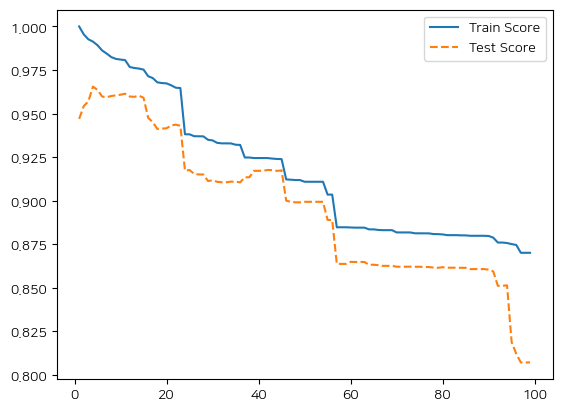

In [10]:
plt.plot(para_leaf, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_leaf, test_score, linestyle = "--", label = "Test Score")
plt.legend() ; plt.show()

최소잎의 개수가 0에서 20개인 부근에서 가장 성능이 좋은 것을 알 수 있다.

In [11]:
train_score = []; test_score = [ ]; diff = []

para_leaf = [n_leaf for n_leaf in range(1, 20)]

for v_min_samples_leaf in para_leaf:
    tree = DecisionTreeRegressor(random_state=1234, min_samples_leaf=v_min_samples_leaf)
    tree.fit(df_train_x, df_train_y)
    train_score.append(tree.score(df_train_x, df_train_y))
    test_score.append(tree.score(df_test_x, df_test_y))
    diff.append(tree.score(df_train_x, df_train_y)-tree.score(df_test_x, df_test_y))

df_score_leaf = pd.DataFrame()
df_score_leaf["MinSamplesLeaf"] = para_leaf
df_score_leaf["TrainScore"] = train_score
df_score_leaf["TestScore"] = test_score
df_score_leaf["Diff"] = diff

df_score_leaf.round(5).sort_values(by = "TestScore", ascending = False)

,MinSamplesLeaf,TrainScore,TestScore,Diff
3,4,0.99132,0.96550,0.02582
4,5,0.98921,0.96353,0.02568
10,11,0.98066,0.96137,0.01929
9,10,0.98099,0.96082,0.02017
8,9,0.98138,0.96042,0.02095
13,14,0.97582,0.96022,0.01560
7,8,0.98239,0.96009,0.02231
11,12,0.97671,0.95978,0.01694
5,6,0.98621,0.95975,0.02646
12,13,0.97616,0.95960,0.01656


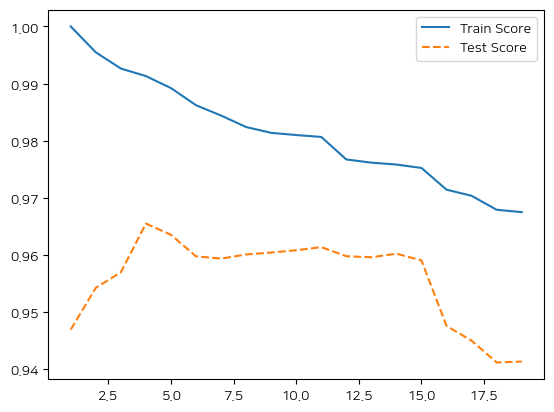

In [12]:
plt.plot(para_leaf, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_leaf, test_score, linestyle = "--", label = "Test Score")
plt.legend() ; plt.show()

### 분리 노드 최소 자료 수 선정

In [13]:
train_score = []; test_score = []; diff = []

para_split = [n_split for n_split in range(1, 100)]

for v_min_samples_split in para_split:
    tree = DecisionTreeRegressor(random_state=1234, min_samples_leaf=4
                                 , min_samples_split=v_min_samples_split)
    tree.fit(df_train_x, df_train_y)
    train_score.append(tree.score(df_train_x, df_train_y))
    test_score.append(tree.score(df_test_x, df_test_y))
    diff.append(tree.score(df_train_x, df_train_y)-tree.score(df_test_x, df_test_y))

df_score_split = pd.DataFrame()
df_score_split["MinSamplesSplit"] = para_split
df_score_split["TrainScore"] = train_score
df_score_split["TestScore"] = test_score
df_score_split["Diff"] = diff

df_score_split.round(5)

,MinSamplesSplit,TrainScore,TestScore,Diff
0,1,0.99132,0.96550,0.02582
1,2,0.99132,0.96550,0.02582
2,3,0.99132,0.96550,0.02582
3,4,0.99132,0.96550,0.02582
4,5,0.99132,0.96550,0.02582
...,...,...,...,...
94,95,0.95534,0.93544,0.01990
95,96,0.95534,0.93544,0.01990
96,97,0.95534,0.93544,0.01990
97,98,0.95534,0.93544,0.01990


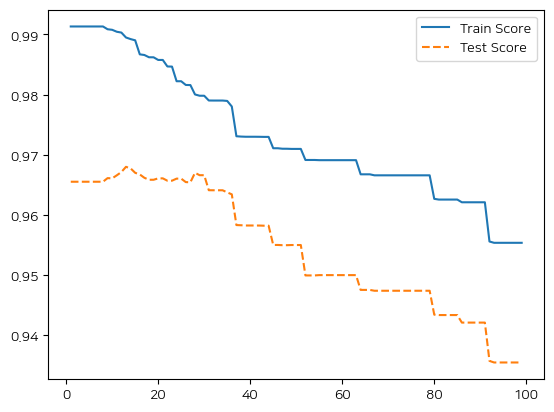

In [14]:
plt.plot(para_split, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_split, test_score, linestyle = "--", label = "Test Score")
plt.legend() ; plt.show()

10에서 40사이에서 성능이 가장 우수하다.

In [15]:
train_score = []; test_score = []; diff = []

para_split = [n_split for n_split in range(10, 40)]

for v_min_samples_split in para_split:
    tree = DecisionTreeRegressor(random_state=1234, min_samples_leaf=4
                                 , min_samples_split=v_min_samples_split)
    tree.fit(df_train_x, df_train_y)
    train_score.append(tree.score(df_train_x, df_train_y))
    test_score.append(tree.score(df_test_x, df_test_y))
    diff.append(tree.score(df_train_x, df_train_y)-tree.score(df_test_x, df_test_y))

df_score_split = pd.DataFrame()
df_score_split["MinSamplesSplit"] = para_split
df_score_split["TrainScore"] = train_score
df_score_split["TestScore"] = test_score
df_score_split["Diff"] = diff

df_score_split.round(5).sort_values(by = "TestScore", ascending = False)

,MinSamplesSplit,TrainScore,TestScore,Diff
3,13,0.98948,0.96797,0.02151
4,14,0.98922,0.96772,0.02150
2,12,0.99030,0.96711,0.02319
5,15,0.98901,0.96698,0.02203
18,28,0.98001,0.96698,0.01303
6,16,0.98668,0.96671,0.01997
20,30,0.97980,0.96658,0.01321
19,29,0.97980,0.96658,0.01322
1,11,0.99044,0.96656,0.02388
7,17,0.98657,0.96615,0.02042


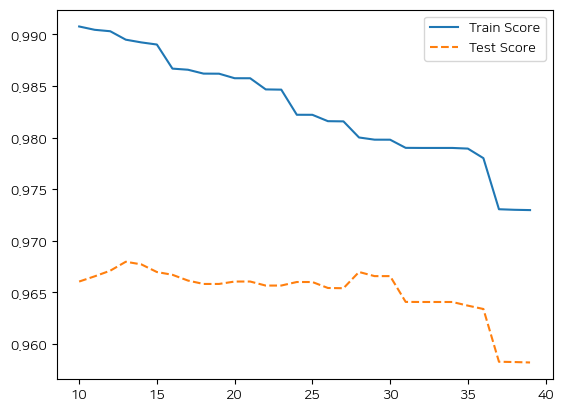

In [16]:
plt.plot(para_split, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_split, test_score, linestyle = "--", label = "Test Score")
plt.legend() ; plt.show()

### 최대 깊이 선정

In [17]:
train_score = []; test_score = []
para_depth = [depth for depth in range(1, 20)]

for v_max_depth in para_depth:
    tree = DecisionTreeRegressor(random_state=1234, min_samples_leaf=4, min_samples_split=13
                                  , max_depth = v_max_depth)
    tree.fit(df_train_x, df_train_y)
    train_score.append(tree.score(df_train_x, df_train_y))
    test_score.append(tree.score(df_test_x, df_test_y))

df_score_depth = pd.DataFrame()
df_score_depth["Depth"] = para_depth
df_score_depth["TrainScore"] = train_score
df_score_depth["TestScore"] = test_score

df_score_depth.round(3)

,Depth,TrainScore,TestScore
0,1,0.633,0.586
1,2,0.834,0.812
2,3,0.888,0.861
3,4,0.959,0.938
4,5,0.975,0.956
5,6,0.985,0.962
6,7,0.987,0.963
7,8,0.989,0.967
8,9,0.989,0.968
9,10,0.989,0.968


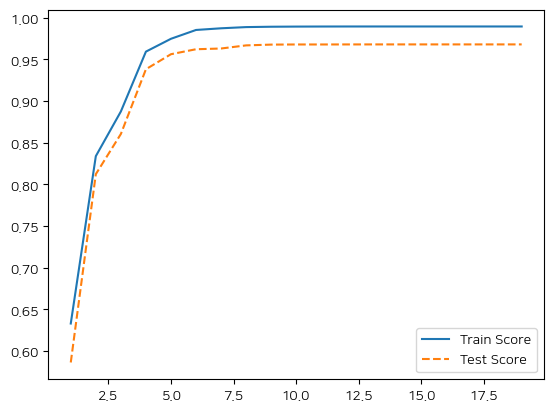

In [18]:
plt.plot(para_depth, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_depth, test_score, linestyle = "--", label = "Test Score")
plt.legend()

Depth가 9 이후로 성능이 변화하지 않는다.

## 최종 모델 선정

In [19]:
tree_final = DecisionTreeRegressor(random_state=1234, min_samples_leaf=4, min_samples_split=13, max_depth = 9 )
tree_final.fit(df_train_x, df_train_y)

export_graphviz(tree_final, out_file="tree_depth.dot",
                feature_names = df_train_x.columns, impurity = True, filled = True)
with open("tree_depth.dot") as f:
    dot_graph = f.read()
src = graphviz.Source(dot_graph)
src.view()

'Source.gv.pdf'

In [20]:
df_importance = pd.DataFrame()
df_importance["Feature"] = df_train_x.columns
df_importance["Importance"] = tree_final.feature_importances_

df_importance.sort_values("Importance", ascending=False, inplace = True)
df_importance.round(3)

,Feature,Importance
3,흡연여부,0.640
4,보장범위,0.145
1,BMI,0.141
0,나이,0.057
5,납입기간,0.014
2,자녀수,0.002
10,납부유형_카드,0.000
6,성별_여성,0.000
8,가입유형_홈쇼핑,0.000
7,가입유형_인터넷,0.000


Text(0, 0.5, '변수')

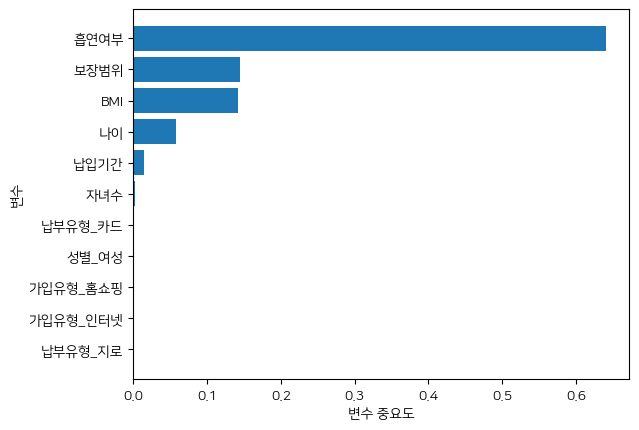

In [21]:
df_importance.sort_values("Importance", ascending=True, inplace = True)
coordinates = range(len(df_importance))
plt.barh(y = coordinates, width = df_importance["Importance"])
plt.yticks(coordinates, df_importance["Feature"])
plt.xlabel("변수 중요도")
plt.ylabel("변수")

In [22]:
print("training set의 R-squared 값: {:.3f}%".format(tree_final.score(df_train_x, df_train_y)*100))
print("test set의 R-squared 값: {:.3f}%".format(tree_final.score(df_test_x, df_test_y)*100))

training set의 R-squared 값: 98.918%
test set의 R-squared 값: 96.774%


## 의사결정나무 결론

의사결정나무에서 가장 영향을 많이 주는 요소는 "흡연 여부"였다. 그리고 보장범위, BMI, 나이, 납입기간 순으로 영향을 준다는 사실을 알 수 있었다.<br>
최적의 의사결정나무를 위한 요소로는 최소 잎사귀 노드 4, 최소 분리 노드 13, 최대 깊이 9개가 나왔다.<br>
이를 통하여 나온 성능값은 96.774%의 데이터를 설명 가능하며 높은 성능을 보여주었다.

## 랜덤포레스트

In [23]:
rf_uncustomized = RandomForestRegressor(random_state=1234)
rf_uncustomized.fit(df_train_x, df_train_y)
print("Score on training set: {:.3f}".format(rf_uncustomized.score(df_train_x, df_train_y)))
print("Score on test set: {:.3f}".format(rf_uncustomized.score(df_test_x, df_test_y)))

Score on training set: 0.997
Score on test set: 0.962


## 나무 수 선정

In [24]:
train_score = []; test_score = []

para_n_tree = [n_tree for n_tree in range(1, 100)]

for v_n_estimators in para_n_tree:
    rf = RandomForestRegressor(n_estimators = v_n_estimators, random_state = 1234)
    rf.fit(df_train_x, df_train_y)
    train_score.append(rf.score(df_train_x, df_train_y))
    test_score.append(rf.score(df_test_x, df_test_y))

df_score_n = pd.DataFrame()
df_score_n["n_estimators"] = para_n_tree
df_score_n["TrainScore"] = train_score
df_score_n["TestScore"] = test_score

df_score_n.round(3)

,n_estimators,TrainScore,TestScore
0,1,0.981,0.954
1,2,0.986,0.963
2,3,0.990,0.965
3,4,0.991,0.966
4,5,0.994,0.966
...,...,...,...
94,95,0.997,0.962
95,96,0.997,0.962
96,97,0.997,0.962
97,98,0.997,0.962


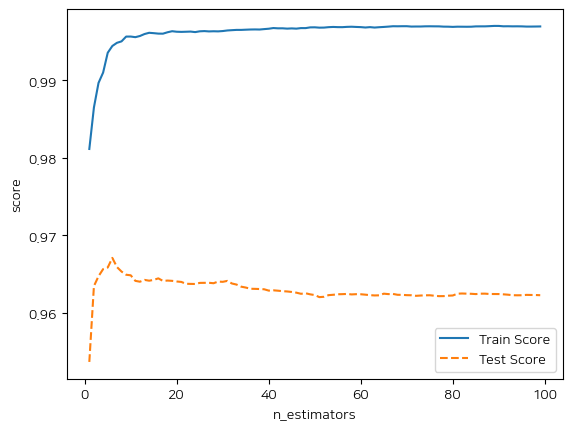

In [25]:
plt.plot(para_n_tree, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_n_tree, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("n_estimators")
plt.legend()

0~10 사이에서 가장 큰 값을 가진다.

In [26]:
train_score = []; test_score = []; diff = []

para_n_tree = [n_tree for n_tree in range(1, 10)]

for v_n_estimators in para_n_tree:
    rf = RandomForestRegressor(n_estimators = v_n_estimators, random_state = 1234)
    rf.fit(df_train_x, df_train_y)
    train_score.append(rf.score(df_train_x, df_train_y))
    test_score.append(rf.score(df_test_x, df_test_y))
    diff.append(rf.score(df_train_x, df_train_y)-rf.score(df_test_x, df_test_y))

df_score_n = pd.DataFrame()
df_score_n["n_estimators"] = para_n_tree
df_score_n["TrainScore"] = train_score
df_score_n["TestScore"] = test_score
df_score_n["Diff"] = diff

df_score_n.round(5).sort_values(by = "TestScore", ascending = False)

,n_estimators,TrainScore,TestScore,Diff
5,6,0.99442,0.96707,0.02735
6,7,0.99483,0.96589,0.02894
4,5,0.99355,0.96583,0.02772
3,4,0.99099,0.96563,0.02536
7,8,0.99502,0.96531,0.02971
8,9,0.99563,0.96490,0.03074
2,3,0.98966,0.96471,0.02495
1,2,0.98649,0.96343,0.02305
0,1,0.98113,0.95365,0.02748


### 잎사귀 노드 최소 자료 수 선정

In [27]:
train_score = []; test_score = []

para_leaf = [n_leaf for n_leaf in range(1, 100)]

for v_min_samples_leaf in para_leaf:
    rf = RandomForestRegressor(random_state=1234, n_estimators = 6,
                                min_samples_leaf = v_min_samples_leaf)
    rf.fit(df_train_x, df_train_y)
    train_score.append(rf.score(df_train_x, df_train_y))
    test_score.append(rf.score(df_test_x, df_test_y))

df_score_leaf = pd.DataFrame()
df_score_leaf["MinSamplesLeaf"] = para_leaf
df_score_leaf["TrainScore"] = train_score
df_score_leaf["TestScore"] = test_score

df_score_leaf.round(3)

,MinSamplesLeaf,TrainScore,TestScore
0,1,0.994,0.967
1,2,0.991,0.965
2,3,0.988,0.966
3,4,0.985,0.961
4,5,0.983,0.959
...,...,...,...
94,95,0.729,0.691
95,96,0.729,0.691
96,97,0.728,0.691
97,98,0.726,0.689


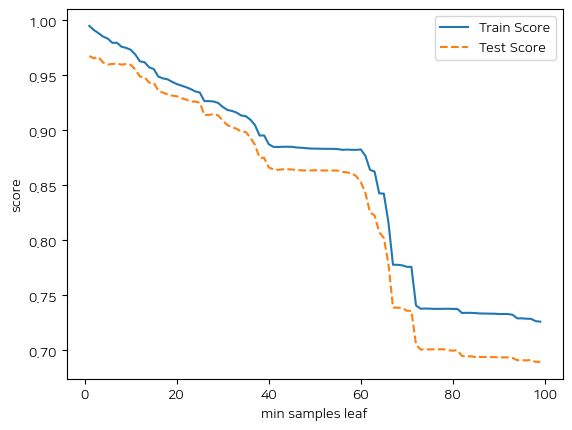

In [28]:
plt.plot(para_leaf, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_leaf, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("min samples leaf")
plt.legend()

0에서 20사이에서 가장 값이 높다.

In [29]:
train_score = []; test_score = []; diff = []

para_leaf = [n_leaf for n_leaf in range(1, 20)]

for v_min_samples_leaf in para_leaf:
    rf = RandomForestRegressor(random_state=1234, n_estimators = 6,
                                min_samples_leaf = v_min_samples_leaf)
    rf.fit(df_train_x, df_train_y)
    train_score.append(rf.score(df_train_x, df_train_y))
    test_score.append(rf.score(df_test_x, df_test_y))
    diff.append(rf.score(df_train_x, df_train_y)-rf.score(df_test_x, df_test_y))

df_score_leaf = pd.DataFrame()
df_score_leaf["MinSamplesLeaf"] = para_leaf
df_score_leaf["TrainScore"] = train_score
df_score_leaf["TestScore"] = test_score
df_score_leaf["Diff"] = diff

df_score_leaf.round(5).sort_values(by = "TestScore", ascending = False)

,MinSamplesLeaf,TrainScore,TestScore,Diff
0,1,0.99442,0.96707,0.02735
2,3,0.98782,0.96622,0.02161
1,2,0.99064,0.96496,0.02568
3,4,0.98473,0.96116,0.02357
6,7,0.97912,0.96037,0.01875
8,9,0.97450,0.95993,0.01457
5,6,0.97910,0.95988,0.01921
4,5,0.98291,0.95938,0.02353
7,8,0.97553,0.95926,0.01628
9,10,0.97277,0.95902,0.01375


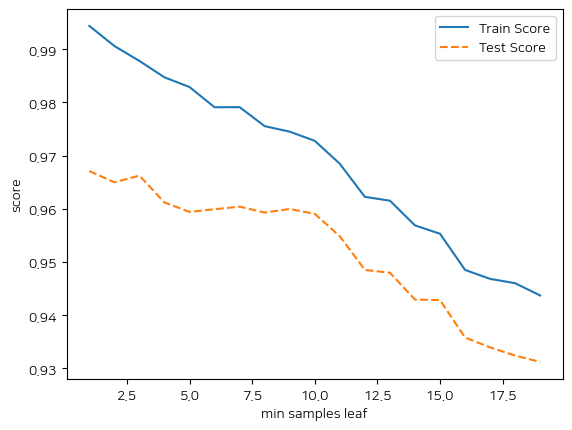

In [30]:
plt.plot(para_leaf, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_leaf, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("min samples leaf")
plt.legend()

### 분리 노드 최소 자료 수 선정

In [31]:
train_score = []; test_score = []

para_split = [n_split for n_split in range(1, 100)]

for v_min_samples_split in para_split:
    rf = RandomForestRegressor(random_state=1234, n_estimators = 6, min_samples_leaf = 1,
                               min_samples_split = v_min_samples_split)
    rf.fit(df_train_x, df_train_y)
    train_score.append(rf.score(df_train_x, df_train_y))
    test_score.append(rf.score(df_test_x, df_test_y))


df_score_split = pd.DataFrame()
df_score_split["MinSamplesSplit"] = para_split
df_score_split["TrainScore"] = train_score
df_score_split["TestScore"] = test_score
df_score_split.round(3)

,MinSamplesSplit,TrainScore,TestScore
0,1,0.994,0.967
1,2,0.994,0.967
2,3,0.994,0.966
3,4,0.993,0.965
4,5,0.992,0.965
...,...,...,...
94,95,0.938,0.927
95,96,0.935,0.925
96,97,0.932,0.922
97,98,0.920,0.910


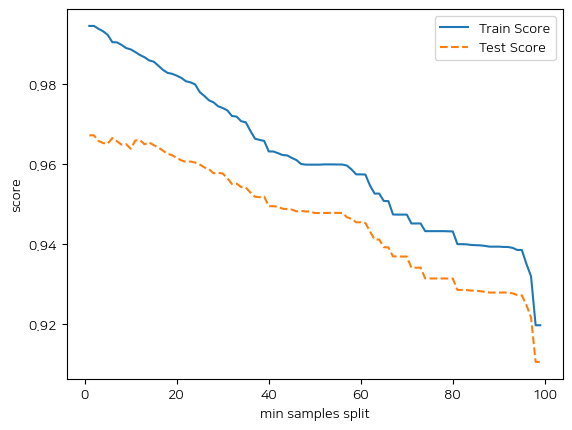

In [32]:
plt.plot(para_split, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_split, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("min samples split")
plt.legend()

0~10에서 가장 높은 값을 보이고 있다.

In [33]:
train_score = []; test_score = []; diff = []

para_split = [n_split for n_split in range(1, 10)]

for v_min_samples_split in para_split:
    rf = RandomForestRegressor(random_state=1234, n_estimators = 6, min_samples_leaf = 1,
                               min_samples_split = v_min_samples_split)
    rf.fit(df_train_x, df_train_y)
    train_score.append(rf.score(df_train_x, df_train_y))
    test_score.append(rf.score(df_test_x, df_test_y))
    diff.append(rf.score(df_train_x, df_train_y)-rf.score(df_test_x, df_test_y))


df_score_split = pd.DataFrame()
df_score_split["MinSamplesSplit"] = para_split
df_score_split["TrainScore"] = train_score
df_score_split["TestScore"] = test_score
df_score_split["Diff"] = diff

df_score_split.round(5).sort_values(by = "TestScore", ascending = False)

,MinSamplesSplit,TrainScore,TestScore,Diff
0,1,0.99442,0.96707,0.02735
1,2,0.99442,0.96707,0.02735
5,6,0.99035,0.96640,0.02396
2,3,0.99369,0.96567,0.02802
6,7,0.99031,0.96557,0.02474
3,4,0.99308,0.96513,0.02795
4,5,0.99218,0.96500,0.02718
8,9,0.98889,0.96486,0.02403
7,8,0.98968,0.96475,0.02493


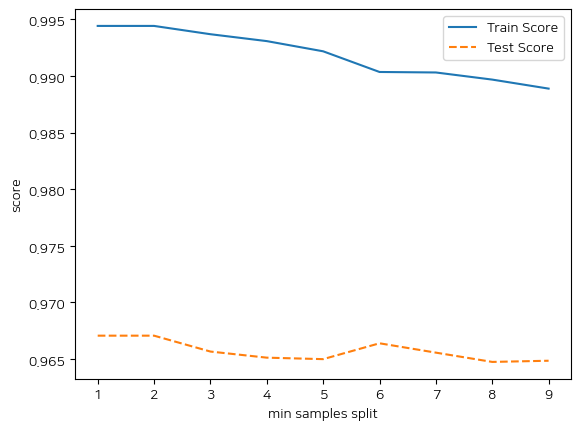

In [34]:
plt.plot(para_split, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_split, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("min samples split")
plt.legend()

### 최대 깊이 선정

In [35]:
train_score = []; test_score = []; diff = []

para_depth = [depth for depth in range(1, 20)]

for v_max_depth in para_depth:
    rf = RandomForestRegressor(random_state=1234, n_estimators = 6,
                               min_samples_leaf = 1, min_samples_split = 2,
                               max_depth = v_max_depth)
    rf.fit(df_train_x, df_train_y)
    train_score.append(rf.score(df_train_x, df_train_y))
    test_score.append(rf.score(df_test_x, df_test_y))
    diff.append(rf.score(df_train_x, df_train_y)-rf.score(df_test_x, df_test_y))

df_score_depth = pd.DataFrame()
df_score_depth["Depth"] = para_depth
df_score_depth["TrainScore"] = train_score
df_score_depth["TestScore"] = test_score
df_score_depth["Diff"] = diff

df_score_depth.round(3).sort_values(by = "TestScore", ascending = False)

,Depth,TrainScore,TestScore,Diff
18,19,0.994,0.967,0.027
16,17,0.994,0.967,0.028
17,18,0.994,0.966,0.028
5,6,0.989,0.966,0.023
14,15,0.995,0.966,0.029
13,14,0.995,0.966,0.029
12,13,0.995,0.966,0.029
11,12,0.995,0.966,0.029
10,11,0.995,0.965,0.030
15,16,0.995,0.965,0.029


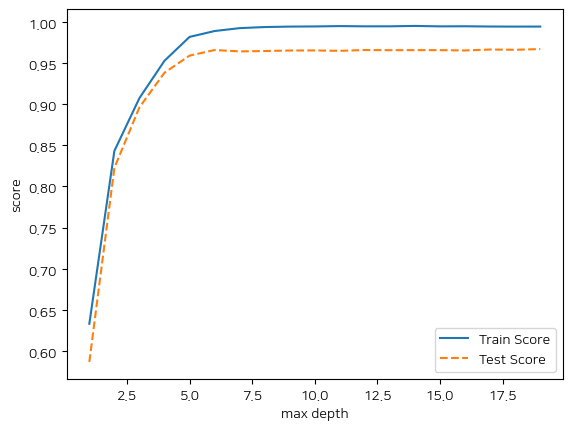

In [36]:
plt.plot(para_depth, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_depth, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("max depth")
plt.legend()

전반적으로 비슷한 Testscore에서 Diff가 가장 작은 Depth를 선정하였다.

## 최종 모델 선정

In [37]:
rf_final = RandomForestRegressor(random_state=1234, n_estimators = 6, min_samples_leaf = 1,
                                 min_samples_split = 2, max_depth = 6)
rf_final.fit(df_train_x, df_train_y)

export_graphviz(rf_final.estimators_[0], out_file="rfr_final_0.dot", feature_names = df_train_x.columns , 
                impurity = True, filled = True)

with open("rfr_final_0.dot") as f:
    dot_graph = f.read()
src = graphviz.Source(dot_graph)
src.view()

'Source.gv.pdf'

In [38]:
df_importance = pd.DataFrame()
df_importance["Feature"] = df_train_x.columns
df_importance["Importance"] = rf_final.feature_importances_

df_importance.sort_values("Importance", ascending=False, inplace = True)
df_importance.round(3)

,Feature,Importance
3,흡연여부,0.643
1,BMI,0.143
4,보장범위,0.110
0,나이,0.092
5,납입기간,0.007
2,자녀수,0.004
9,납부유형_지로,0.000
6,성별_여성,0.000
10,납부유형_카드,0.000
7,가입유형_인터넷,0.000


Text(0, 0.5, '변수')

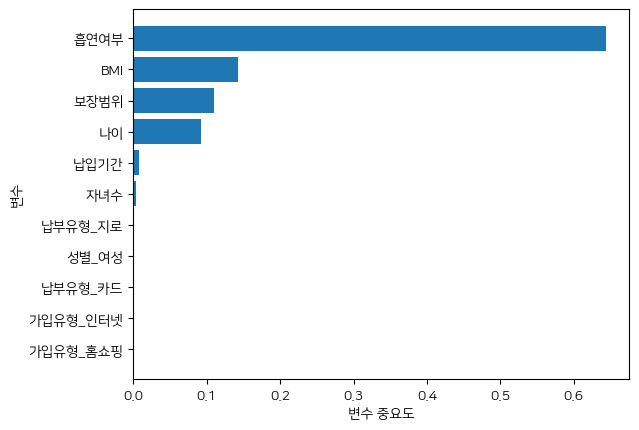

In [39]:
df_importance.sort_values("Importance", ascending=True, inplace = True)
coordinates = range(len(df_importance))
plt.barh(y = coordinates, width = df_importance["Importance"])
plt.yticks(coordinates, df_importance["Feature"])
plt.xlabel("변수 중요도")
plt.ylabel("변수")

In [40]:
print("training set의 R-squared 값: {:.3f}%".format(rf_final.score(df_train_x, df_train_y)*100))
print("test set의 R-squared 값: {:.3f}%".format(rf_final.score(df_test_x, df_test_y)*100))

training set의 R-squared 값: 98.899%
test set의 R-squared 값: 96.588%


## 결론

랜덤포레스트에서 가장 영향을 많이 주는 요소는 "흡연 여부"였다. 그리고 BMI, 보장범위, 나이, 납입기간, 자녀 순으로 영향을 준다는 사실을 알 수 있었다.<br>
의사결정나무와 다르게 중요한 변수의 수가 더 많았으며, 중요도도 BMI와 보장도가 다르다는 결론을 도출했다.
최적의 랜덤포레스트를 위한 요소로는 나무 수 6, 최소 잎사귀 노드 1, 최소 분리 노드 2, 최대 깊이 6이 나왔다.<br>
이를 통하여 나온 성능값은 96.588%의 데이터를 설명 가능하며 의사결정나무보다는 낮지만 준수한 성능을 보여주었다.

## 그래디언트 부스팅

In [41]:
gb_uncustomized = GradientBoostingRegressor(random_state=1234)
gb_uncustomized.fit(df_train_x, df_train_y)
print("Score on training set: {:.3f}".format(gb_uncustomized.score (df_train_x, df_train_y)))
print("Score on test set: {:.3f}".format(gb_uncustomized.score (df_test_x, df_test_y)))

Score on training set: 0.990
Score on test set: 0.962


## 트리 개수 선정

In [42]:
train_score = []; test_score = []; diff = []
para_n_tree = [n_tree for n_tree in range(1, 100)]

for v_n_estimators in para_n_tree:
    gb = GradientBoostingRegressor(random_state = 1234, n_estimators = v_n_estimators)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))
    diff.append(gb.score(df_train_x, df_train_y)-gb.score(df_test_x, df_test_y))

df_score_n = pd.DataFrame()
df_score_n["Estimators"] = para_n_tree
df_score_n["TrainScore"] = train_score
df_score_n["TestScore"] = test_score
df_score_n["Diff"] = diff

df_score_n.round(3).sort_values(by = "TestScore", ascending = False)

,Estimators,TrainScore,TestScore,Diff
98,99,0.990,0.962,0.028
86,87,0.989,0.962,0.027
74,75,0.988,0.962,0.027
76,77,0.988,0.962,0.027
77,78,0.988,0.962,0.027
...,...,...,...,...
4,5,0.599,0.574,0.025
3,4,0.524,0.501,0.022
2,3,0.427,0.405,0.021
1,2,0.306,0.289,0.016


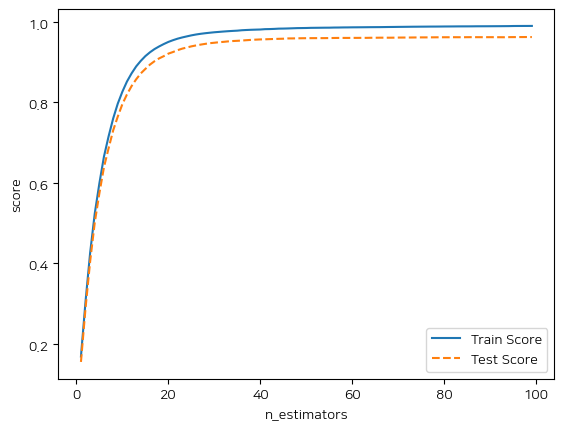

In [43]:
plt.plot(para_n_tree, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_n_tree, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("n_estimators")
plt.legend()

In [44]:
df_score_n["TestScore_r"] = df_score_n["TestScore"].round(3)
df_score_n[df_score_n["TestScore_r"] == 0.962].sort_values(by="Diff", ascending=True).head()

,Estimators,TrainScore,TestScore,Diff,TestScore_r
74,75,0.988247,0.961581,0.026666,0.962
78,79,0.988542,0.961870,0.026672,0.962
77,78,0.988462,0.961773,0.026689,0.962
75,76,0.988317,0.961581,0.026736,0.962
79,80,0.988663,0.961916,0.026747,0.962


TestScore의 값이 0.962에 근사하게 증가하는 움직임을 가진다. 그 중 TrainScore와의 값이 가장 작은 75를 선정한다.

### 잎사귀 노드 최소 자료 수 선정

In [45]:
train_score = []; test_score = []; diff = []

para_leaf = [n_leaf for n_leaf in range(1, 100)]

for v_min_samples_leaf in para_leaf:
    gb = GradientBoostingRegressor(random_state=1234, n_estimators = 75,
                                   min_samples_leaf = v_min_samples_leaf)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))
    diff.append(gb.score(df_train_x, df_train_y)-gb.score(df_test_x, df_test_y))

df_score_leaf = pd.DataFrame()
df_score_leaf["MinSamplesLeaf"] = para_leaf
df_score_leaf["TrainScore"] = train_score
df_score_leaf["TestScore"] = test_score
df_score_leaf["Diff"] = diff

df_score_leaf.round(5).sort_values(by = "TestScore", ascending = False)

,MinSamplesLeaf,TrainScore,TestScore,Diff
11,12,0.98527,0.96233,0.02294
38,39,0.97479,0.96172,0.01307
0,1,0.98825,0.96158,0.02667
3,4,0.98745,0.96155,0.02590
13,14,0.98468,0.96153,0.02315
...,...,...,...,...
98,99,0.95802,0.93851,0.01951
97,98,0.95805,0.93829,0.01976
94,95,0.96162,0.93803,0.02359
96,97,0.95807,0.93789,0.02018


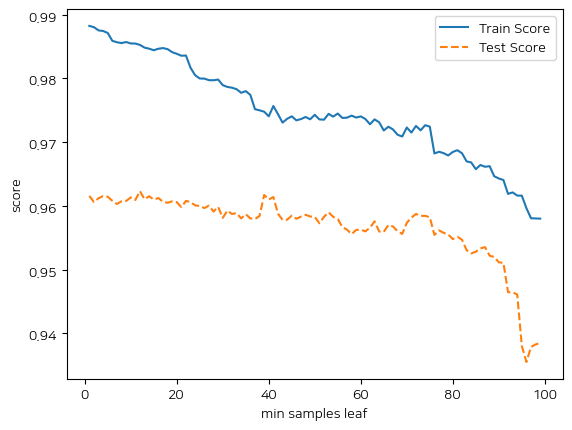

In [46]:
plt.plot(para_leaf, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_leaf, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("min samples leaf")
plt.legend()

In [47]:
train_score = []; test_score = []; diff = []

para_leaf = [n_leaf for n_leaf in range(1, 20)]

for v_min_samples_leaf in para_leaf:
    gb = GradientBoostingRegressor(random_state=1234, n_estimators = 75,
                                   min_samples_leaf = v_min_samples_leaf)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))
    diff.append(gb.score(df_train_x, df_train_y)-gb.score(df_test_x, df_test_y))

df_score_leaf = pd.DataFrame()
df_score_leaf["MinSamplesLeaf"] = para_leaf
df_score_leaf["TrainScore"] = train_score
df_score_leaf["TestScore"] = test_score
df_score_leaf["Diff"] = diff

df_score_leaf.round(5).sort_values(by = "TestScore", ascending = False)

,MinSamplesLeaf,TrainScore,TestScore,Diff
11,12,0.98527,0.96233,0.02294
0,1,0.98825,0.96158,0.02667
3,4,0.98745,0.96155,0.02590
13,14,0.98468,0.96153,0.02315
4,5,0.98715,0.96145,0.02570
9,10,0.98550,0.96133,0.02416
15,16,0.98467,0.96124,0.02343
2,3,0.98755,0.96122,0.02633
12,13,0.98484,0.96107,0.02378
14,15,0.98443,0.96102,0.02342


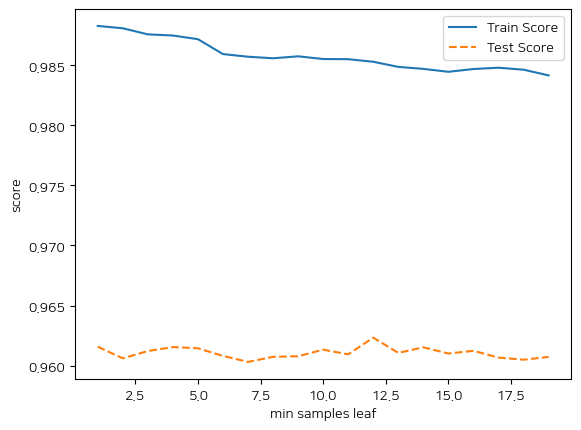

In [48]:
plt.plot(para_leaf, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_leaf, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("min samples leaf")
plt.legend()

전반적으로 비슷한 값을 가지지만 12에서 가장 높은 값을 가진다.

### 분리 노드 최소 자료 수 선정

In [49]:
train_score = []; test_score = []; diff = []
para_split = [n_split for n_split in range(1, 100)]

for v_min_samples_split in para_split:
    gb = GradientBoostingRegressor(random_state=1234, n_estimators = 75, min_samples_leaf = 12,
                                   min_samples_split = v_min_samples_split)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))
    diff.append(gb.score(df_train_x, df_train_y)-gb.score(df_test_x, df_test_y))

df_score_split = pd.DataFrame()
df_score_split["MinSamplesSplit"] = para_split
df_score_split["TrainScore"] = train_score
df_score_split["TestScore"] = test_score
df_score_split["Diff"] = diff

df_score_split.round(5).sort_values(by = "TestScore", ascending = False)

,MinSamplesSplit,TrainScore,TestScore,Diff
96,97,0.98283,0.96292,0.01992
98,99,0.98274,0.96283,0.01991
97,98,0.98274,0.96283,0.01991
78,79,0.98392,0.96270,0.02122
77,78,0.98392,0.96270,0.02122
...,...,...,...,...
85,86,0.98286,0.96081,0.02205
90,91,0.98279,0.96064,0.02215
89,90,0.98279,0.96064,0.02215
88,89,0.98298,0.96041,0.02257


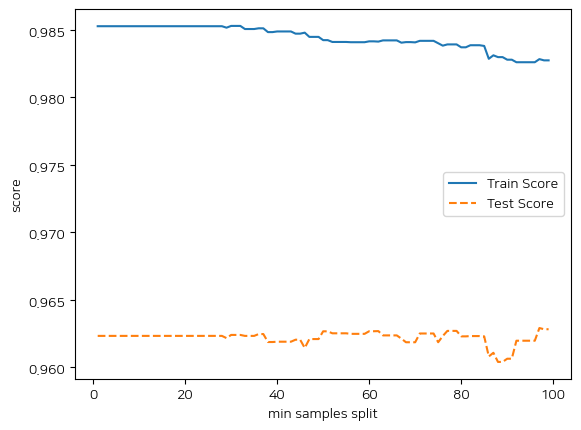

In [50]:
plt.plot(para_split, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_split, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("min samples split")
plt.legend()

In [51]:
df_score_split["TestScore_r"] = df_score_split["TestScore"].round(3)
df_score_split[df_score_split["TestScore_r"] == 0.962].sort_values(by="Diff", ascending=True).head(10)

,MinSamplesSplit,TrainScore,TestScore,Diff,TestScore_r
95,96,0.982600,0.961976,0.020625,0.962
93,94,0.982600,0.961976,0.020625,0.962
92,93,0.982600,0.961976,0.020625,0.962
91,92,0.982600,0.961976,0.020625,0.962
94,95,0.982600,0.961976,0.020625,0.962
80,81,0.983706,0.962298,0.021408,0.962
79,80,0.983706,0.962298,0.021408,0.962
75,76,0.983828,0.962324,0.021504,0.962
84,85,0.983807,0.962297,0.021509,0.962
83,84,0.983860,0.962319,0.021540,0.962


0.962로 비슷한 TestScore에서 Diff가 작은 값들을 발견하였다.그 중 가장 작은 92를 선정한다.

### 최대 깊이 선정

In [52]:
train_score = []; test_score = []; diff = []

para_depth = [depth for depth in range(1, 20)]

for v_max_depth in para_depth:
    gb = GradientBoostingRegressor(random_state=1234, n_estimators = 75, min_samples_leaf = 12,
                                   min_samples_split = 92, max_depth = v_max_depth)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))
    diff.append(gb.score(df_train_x, df_train_y)-gb.score(df_test_x, df_test_y))

df_score_depth = pd.DataFrame()
df_score_depth["Depth"] = para_depth
df_score_depth["TrainScore"] = train_score
df_score_depth["TestScore"] = test_score
df_score_depth["Diff"] = diff

df_score_depth.round(5).sort_values(by = "TestScore", ascending = False)

,Depth,TrainScore,TestScore,Diff
4,5,0.98629,0.96308,0.02321
18,19,0.98791,0.96224,0.02567
17,18,0.98791,0.96224,0.02567
16,17,0.98791,0.96224,0.02567
13,14,0.98791,0.96222,0.02569
12,13,0.98792,0.96214,0.02578
15,16,0.98789,0.96212,0.02577
14,15,0.98789,0.96212,0.02577
2,3,0.98260,0.96198,0.02062
3,4,0.98501,0.96197,0.02304


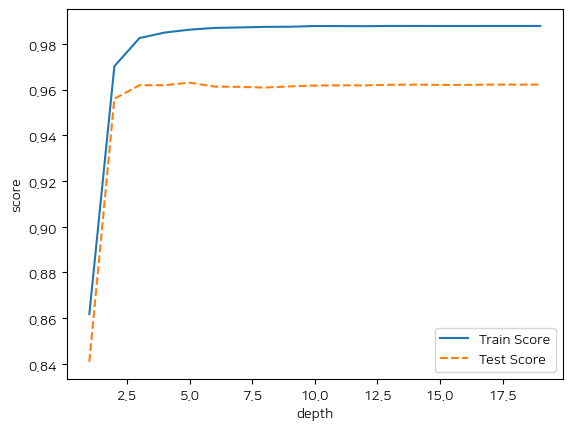

In [53]:
plt.plot(para_depth, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_depth, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("depth")
plt.legend()

TestScore가 가장 큰 5를 Depth로 선정한다.

### 학습률 설정

In [54]:
train_score = []; test_score = []
para_lr = [lr * 0.1 for lr in range(1, 10)]

for v_learning_rate in para_lr:
    gb = GradientBoostingRegressor(random_state=1234, n_estimators = 75, min_samples_leaf = 12,
                                   min_samples_split = 92, max_depth = 5, learning_rate = v_learning_rate)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))

df_score_lr = pd.DataFrame()
df_score_lr["LearningRate"] = para_lr
df_score_lr["TrainScore"] = train_score
df_score_lr["TestScore"] = test_score

df_score_lr.round(3)

,LearningRate,TrainScore,TestScore
0,0.1,0.986,0.963
1,0.2,0.991,0.964
2,0.3,0.993,0.964
3,0.4,0.995,0.967
4,0.5,0.995,0.959
5,0.6,0.996,0.966
6,0.7,0.996,0.965
7,0.8,0.997,0.966
8,0.9,0.997,0.959


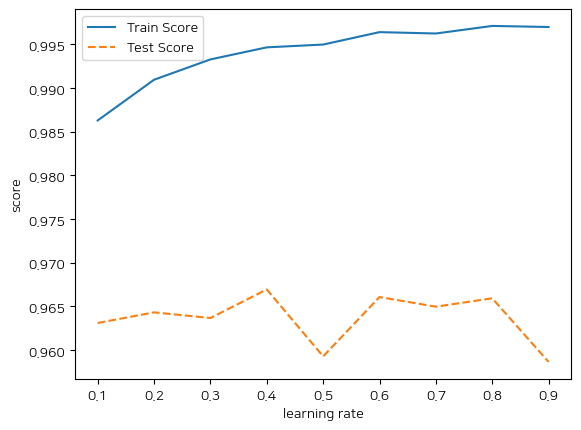

In [55]:
plt.plot(para_lr, train_score, linestyle = "-", label = "Train Score")
plt.plot(para_lr, test_score, linestyle = "--", label = "Test Score")
plt.ylabel("score"); plt.xlabel("learning rate")
plt.legend()

TestScore가 가장 높은 0.4를 채택한다.

## 최종 모델 선정

In [56]:
gb_final = GradientBoostingRegressor(random_state=1234, n_estimators = 75, min_samples_leaf = 12,
                                     min_samples_split = 92, max_depth = 5, learning_rate = 0.4)
gb_final.fit(df_train_x, df_train_y)

export_graphviz(gb_final.estimators_[0,0], out_file="gbr_final_1.dot", feature_names = df_train_x.columns , 
                impurity = True, filled = True)

with open("gbr_final_1.dot") as f:
    dot_graph = f.read()
src = graphviz.Source(dot_graph)
src.view()

'Source.gv.pdf'

In [57]:
df_importance = pd.DataFrame()
df_importance["Feature"] = df_train_x.columns
df_importance["Importance"] = gb_final.feature_importances_

df_importance.sort_values("Importance", ascending=False, inplace = True)
df_importance.round(3)

,Feature,Importance
3,흡연여부,0.637
1,BMI,0.146
4,보장범위,0.133
0,나이,0.071
5,납입기간,0.010
2,자녀수,0.002
6,성별_여성,0.000
10,납부유형_카드,0.000
9,납부유형_지로,0.000
8,가입유형_홈쇼핑,0.000


Text(0, 0.5, '변수')

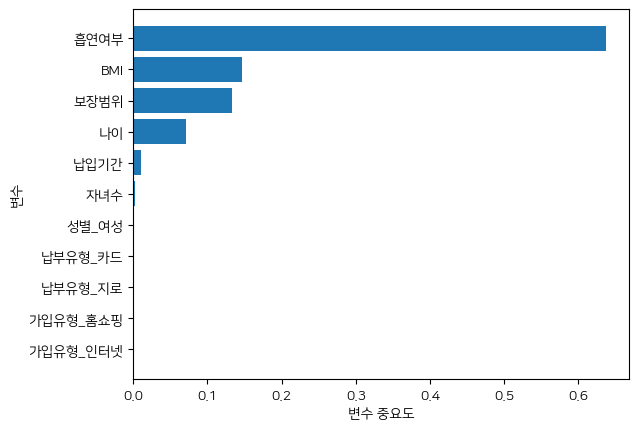

In [58]:
df_importance.sort_values("Importance", ascending=True, inplace = True)
coordinates = range(len(df_importance))
plt.barh(y = coordinates, width = df_importance["Importance"])
plt.yticks(coordinates, df_importance["Feature"])
plt.xlabel("변수 중요도")
plt.ylabel("변수")

In [59]:
print("training set의 R-squared 값: {:.3f}%".format(gb_final.score(df_train_x, df_train_y)*100))
print("test set의 R-squared 값: {:.3f}%".format(gb_final.score(df_test_x, df_test_y)*100))

training set의 R-squared 값: 99.466%
test set의 R-squared 값: 96.692%


## 결론

그래디언트부스팅에서 가장 영향을 많이 주는 요소는 역시 "흡연 여부"였다. 그리고 BMI, 보장범위, 나이, 납입기간순으로 영향을 준다는 사실을 알 수 있었다.<br>
나온 중요요소는 의사결정나무와 더 유사하고, 랜덤포레스트보다는 적었다.
최적의 그래디언트부스팅을 위한 요소로는 나무 수 75, 최소 잎사귀 노드 12, 최소 분리 노드 95, 최대 깊이 5, 학습률 0.4가 나왔다.<br>
이를 통하여 나온 성능값은 96.692%의 데이터를 설명 가능하며 의사결정나무와 랜덤포레스트 사이의 성능을 보여주었다.

## 해석

3가지의 모델을 사용하여 분석한 결과 성능은 의사결정나무 > 그래디언트 부스팅 > 랜덤포레스트 순으로 좋은 것으로 나타났다.<br>
원인을 간략하게 분석해보면 기본적으로 분석의 성능이 우수하여 다양한 데이터를 학습시키면 오히려 과적합의 위험으로 성능이 낮아진 것으로 추정된다.<br>
또한, 3가지 모델 모두 흡연여부, BMI, 보장범위, 나이, 납입기간의 5가지 요소를 중요하게 생각하고 있음을 알 수 있었고,<br>
그중에서도 흡연여부의 중요도가 매우 높았다.<br>
의사결정나무를 활용한 분석은 회귀분석을 활용한 분석보다도 우수한 성능을 자랑하였으며 데이터를 직관적으로 이해하는데 장점이 있음을 알 수 있었다.<br>